In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('gptdata.csv')

In [3]:
df.head()

,feature1,feature2,feature3,target
0,-0.57,1.42,0.49,-9.76
1,-0.99,0.55,1.04,-24.03
2,-0.67,0.15,1.77,45.61
3,0.38,-0.39,-0.11,34.13
4,1.16,-0.02,0.14,86.66


In [4]:
X = df.iloc[:,0:3].values
y = df.iloc[:,-1].values

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_Test = train_test_split(X,y,test_size=0.3,random_state=1)

In [8]:
from sklearn.linear_model import LinearRegression
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [9]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
# Residual
y_pred = model.predict(X_test)
residual = y_test - y_pred

## 1. Linear Relationship

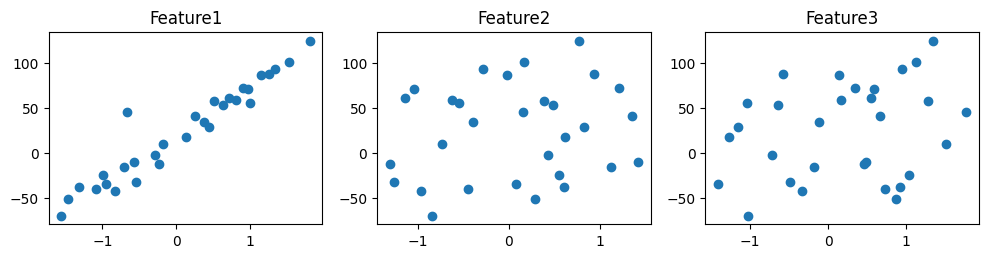

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize = (12,2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title("Feature1")
ax2.scatter(df['feature2'], df['target'])
ax2.set_title("Feature2")
ax3.scatter(df['feature3'], df['target'])
ax3.set_title("Feature3")

plt.show()


## 2. Multicollinearity

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

In [13]:
pd.DataFrame({'vif':vif}, index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.014793,1.018294,1.006205


<Axes: >

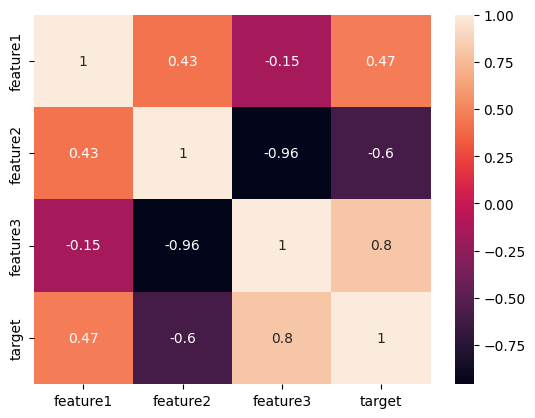

In [15]:
# Another Technique
sns.heatmap(df.iloc[0:3].corr(),annot=True)

## 3. Normality of Residual

<Axes: ylabel='Count'>

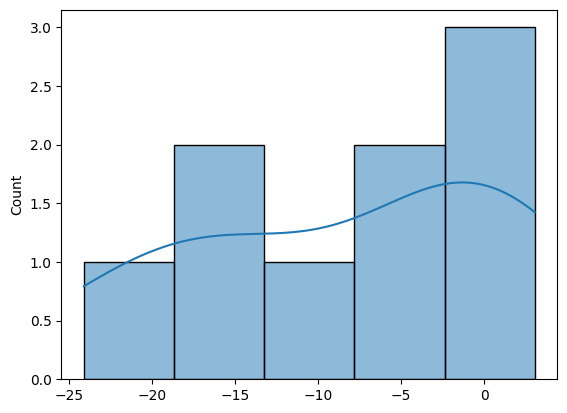

In [ ]:
sns.histplot(residual,kde=True) ## FOR DISTPLOT BUT THAT IS Not present

((array([-1.44573845, -0.91666807, -0.56381839, -0.2709378 ,  0.        ,
          0.2709378 ,  0.56381839,  0.91666807,  1.44573845]),
  array([-24.08736119, -18.24081111, -16.1504726 , -12.75013592,
          -3.36094949,  -2.62001806,  -0.264029  ,   1.36366526,
           3.03891019])),
 (np.float64(10.36956887483514),
  np.float64(-8.119022437354424),
  np.float64(0.9617011200948657)))

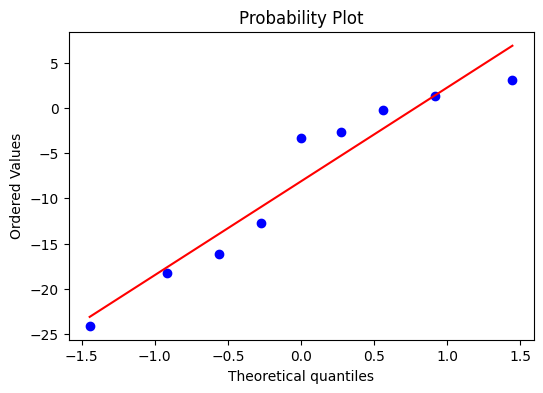

In [19]:
## QQ Plot

import scipy as sp

fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual,plot= ax, fit=True)

## 4. Homoscedasticity

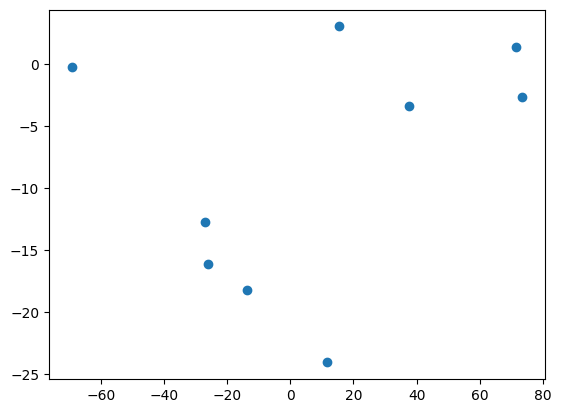

In [20]:
plt.scatter(y_pred,residual)

## 5. Autocorrelation of Residuals

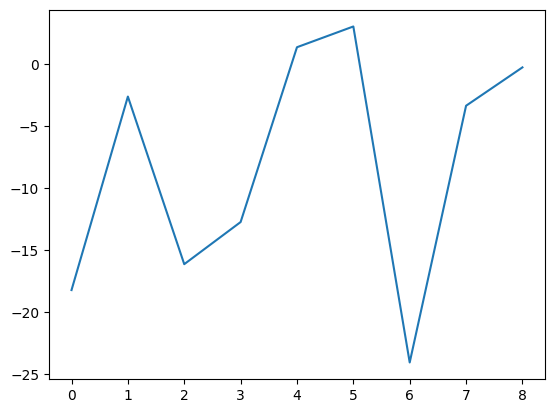

In [21]:
plt.plot(residual)